<a href="https://colab.research.google.com/github/MohammedZaid-AI/Gage/blob/main/sugacane_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
import base64
import json
import urllib.request

api_key="OzNKliqAUCYKvoqzD7y4"
IMAGE_PATH = "YOUR_IMAGE.jpg"

WORKFLOW_URL = (
    "https://serverless.roboflow.com/"
    "muhammed-ismail-maaiz-muhammed-ismail-maaiz/"
    "workflows/sugarcane-disease-classification-1788239328281"
)

with open("/content/figure 19.jpg", "rb") as image_file:
    encoded_image = base64.b64encode(image_file.read()).decode("utf-8")

payload = {
    "inputs": {
        "image": {
            "type": "base64",
            "value": encoded_image
        }
    }
}

request = urllib.request.Request(
    WORKFLOW_URL,
    data=json.dumps(payload).encode("utf-8"),
    headers={
        "Content-Type": "application/json",
        "Authorization": f"Bearer {api_key}"
    },
    method="POST"
)

try:
    with urllib.request.urlopen(request, timeout=120) as response:
        result = json.loads(response.read().decode("utf-8"))

    print(json.dumps(result, indent=2))

except urllib.error.HTTPError as error:
    print("HTTP error:", error.code)
    print(error.read().decode("utf-8"))

{
  "outputs": [
    {
      "output_image": {
        "type": "base64",
        "value": "...",
        "video_metadata": {
          "video_identifier": "image",
          "frame_number": 0,
          "frame_timestamp": "2026-09-01T05:23:31.483512",
          "fps": 30.0,
          "measured_fps": null,
          "comes_from_video_file": null
        }
      },
      "predictions": {
        "inference_id": "7ad3b589-d80f-443e-a66c-95fa9eca31bf",
        "time": 0.017011626972816885,
        "image": {
          "width": 592,
          "height": 1650
        },
        "predictions": [
          {
            "class": "RedRot",
            "class_id": 5,
            "confidence": 0.8383
          }
        ],
        "top": "RedRot",
        "confidence": 0.8383,
        "prediction_type": "classification",
        "parent_id": "image",
        "root_parent_id": "image"
      }
    }
  ],
  "profiler_trace": []
}


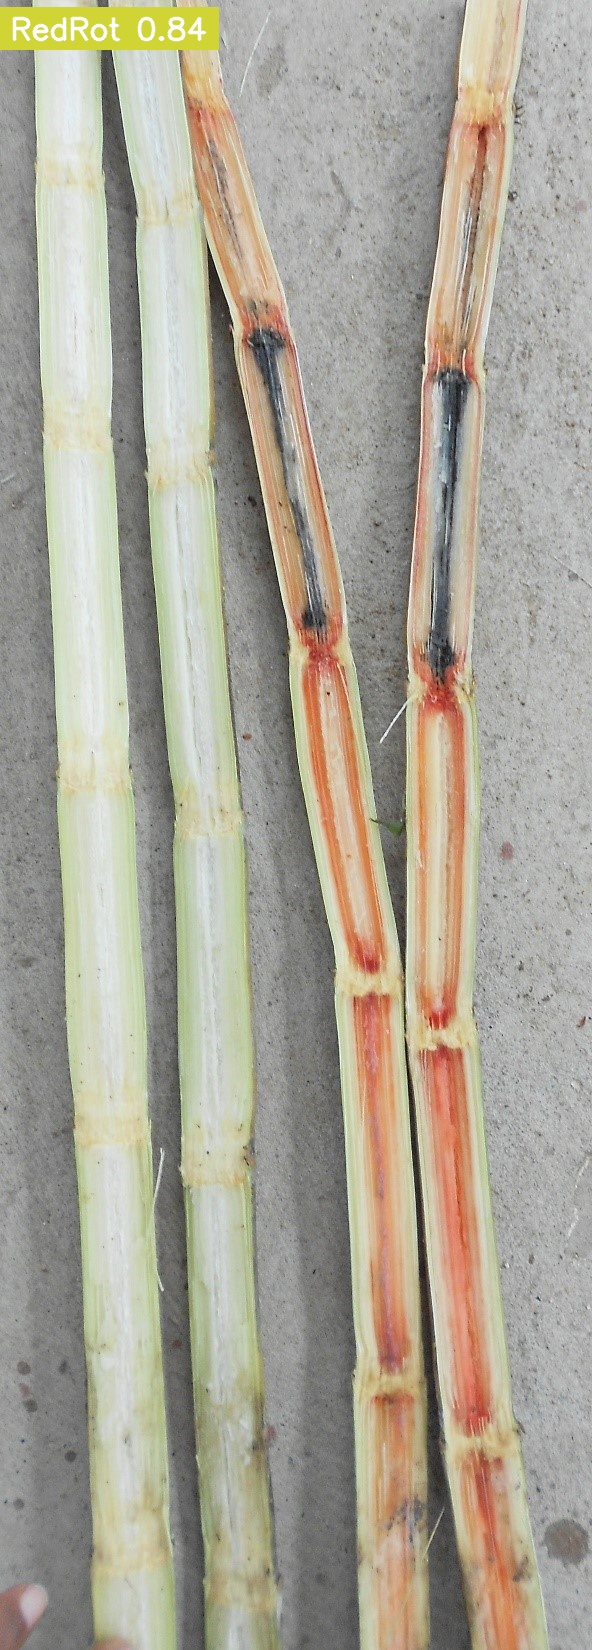

Disease: RedRot
Confidence: 83.8%


In [21]:
import base64
import io
from PIL import Image
from IPython.display import display

# Select the first Workflow output
if isinstance(result, list):
    output = result[0]
elif "outputs" in result:
    output = result["outputs"][0]
else:
    output = result

# Extract Base64 image
image_output = output["output_image"]
image_base64 = (
    image_output["value"]
    if isinstance(image_output, dict)
    else image_output
)

# Remove optional data-URL prefix
if image_base64.startswith("data:"):
    image_base64 = image_base64.split(",", 1)[1]

# Decode and display directly in the cell
image_bytes = base64.b64decode(image_base64)
annotated_image = Image.open(io.BytesIO(image_bytes))

display(annotated_image)

# Print the classification result underneath
prediction = output["predictions"]
print("Disease:", prediction.get("top"))
print(f"Confidence: {prediction.get('confidence', 0):.1%}")
